Logistic Regression function:

 $$
 h_\theta(x) = g(\theta^T x)
 $$
 sigmoid function:
 $$
 g(z) = \frac{1}{1+e^{-z}}
 $$
 对于二分类问题,即 y = 1 or y = 0 h(x)为 y = 1 的概率，如果超过50%即为 y =1 ,
但是也面临一个问题:
1. 如果概率为 0.51 ， 说服力肯定没有 0.99 高
2. 如何让求得的概率更大呢
3. 要求就需要求两个概率，那么怎么能同时兼顾两个概率呢？

因此，引入Loss function:

此时的Loss function:

$$
 P(y|x) = h_\theta(x)^y(1-h_\theta(x))^{1-y}
$$
如果让P 更大，那么说服力就更大.

此时的P 为 Loss function

这里的Loss 体现在什么地方呢？
举一个例子

当y = 1 的时候 ,
$$
P(y|x) = h(x)^1(1-h(x))^0
$$
此时会发现, 只剩下 h(x) 也就是 y_hat , 所以 y_hat -> 1, Loss 此时越接近 1 ,取反也就是越小 ,
此时就体现了 Loss function 能体现出来差异化, 如果最后取了log 那么效果会更好！

此时Loss 解释完了，那么上一下 Loss function的最终形态 **(此时m仅代表样本数量)**
$$
L(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)}log(h_\theta(x^{(i)})) - (1-y^{(i)})log(1-h_\theta(x^{(i)})) \right]
$$
接下来就是用梯度下降去求Loss Function 最小值了！

爬坡的数学公式:
$$
x_{i+1} = x_i + \alpha \frac{d}{dx}L(x)
$$
此时的 α 为学习率


In [59]:

def gradient_descent():
    def f_prime(x_old):
        return -2 * x_old + 4
    x_old = -1
    x_new = 0
    learning_rate = 0.01
    presision = 0.00000001
    while abs(x_new-x_old) > presision:
        x_old = x_new
        x_new = x_old + learning_rate * f_prime(x_old)
    print(x_new)
if __name__ == '__main__':
    gradient_descent()

1.999999515279857


梯度下降和上升差不多，为了方便求，因此采用梯度上升，对于theta，迭代公式如下：
$$
\theta_j := \theta_j + \alpha \frac{\partial L}{\partial \theta_j}
$$
$$
\boxed{
\boldsymbol{\theta} := \boldsymbol{\theta} + \alpha
\sum_{i=1}^{m} \Bigl( y^{(i)} - \sigma\!\bigl(\boldsymbol{\theta}^{\mathsf{T}}\mathbf{x}^{(i)}\bigr) \Bigr) \mathbf{x}^{(i)}
}
$$

In [60]:
import numpy as np
import matplotlib.pyplot as plt
def load_data_set():
    data_mat = []
    label_mat = []
    fr = open('dataset/testSet.txt')
    for line in fr.readlines():
        line_arr = line.strip().split()
        #这里的1.0 实际上是一个bias , 做预测的时候，需要加上bias , 让其拥有实际物理意义
        # y = x1 + x2 + bias
        data_mat.append([1.0, float(line_arr[0]), float(line_arr[1])])
        label_mat.append(int(line_arr[2]))
    fr.close()
    return data_mat , label_mat

In [61]:
import numpy as np
def sigmoid(in_x):
    return 1.0 / (1 + np.exp(-in_x))
def grad_ascent(data_mat_in, class_labels):
    data_mat_in = np.array(data_mat_in)
    #需要变成 m * 1 的矩阵
    class_labels = np.array(class_labels).reshape(-1, 1)
    print(data_mat_in.shape)
    print(class_labels.shape)
    m , n = np.shape(data_mat_in)
    alpha = 0.001
    max_cycles = 500
    weight = np.ones((n,1))
    for k in range(max_cycles):
        tmp_h = sigmoid(data_mat_in @ weight)
        error = class_labels - tmp_h
        #取 mat 的转置
        weight = weight + alpha * data_mat_in.T @ error
    return weight

(100, 3)
(100, 1)
[[ 4.12414349]
 [ 0.48007329]
 [-0.6168482 ]]


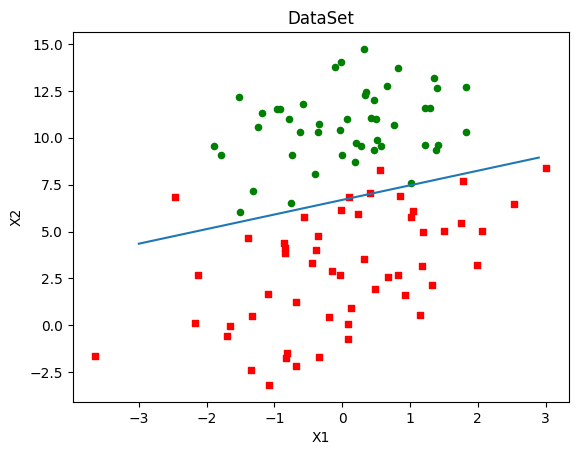

In [62]:
def plot_data_set():
    data_mat , label_mat = load_data_set()
    data_arr = np.array(data_mat)
    n = np.shape(data_arr)[0]
    xcord1 = []
    ycord1 = []
    xcord2 = []
    ycord2 = []
    for i in range(n):
        # 1 代表正样本
        if int(label_mat[i]) == 1:
            #将坐标绘入
            xcord1.append(data_arr[i,1])
            ycord1.append(data_arr[i,2])
        else:
            xcord2.append(data_arr[i,1])
            ycord2.append(data_arr[i,2])
    figure = plt.figure()
    ax = figure.add_subplot(1,1,1)
    ax.scatter(xcord1,ycord1,s=20,c='red',marker='s')
    ax.scatter(xcord2,ycord2,s=20,c='green')
    # thata_0 + theta_1 * x1 + theta_2 * x2 = y
    #找到 = 0 这个边界条件
    x1 = np.arange(-3.0,3.0,0.1) #这里实际上是搞了60个点
    x2 = (-weights[0]-weights[1]*x1)/weights[2]
    ax.plot(x1,x2)
    plt.title('DataSet')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

if __name__ == '__main__':
    data_mat , label_mat = load_data_set()
    weights = grad_ascent(data_mat, label_mat)
    print(weights)
    plot_data_set()